# California Housing Market Analysis

## Business Problem

A real-estate company wants to understand:

- Which factors influence house prices?
- Do richer neighborhoods have higher house values?
- Does house age affect prices?
- Which areas should be targeted for future investments?

The objective is to use exploratory data analysis to uncover pricing drivers and provide actionable business recommendations.

Dataset to Use:
from sklearn.datasets import fetch_california_housing


Q1.
Load the California Housing dataset into a Pandas DataFrame and display:
- First 10 rows
- Last 10 rows
- Shape
- Column names
- Datatypes


In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

housing = fetch_california_housing(as_frame = True)
df = housing.frame.copy()

df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [2]:
df.tail(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20630,3.5673,11.0,5.932584,1.134831,1257.0,2.824719,39.29,-121.32,1.120
20631,3.5179,15.0,6.145833,1.141204,1200.0,2.777778,39.33,-121.40,1.072
20632,3.1250,15.0,6.023377,1.080519,1047.0,2.719481,39.26,-121.45,1.156
20633,2.5495,27.0,5.445026,1.078534,1082.0,2.832461,39.19,-121.53,0.983
20634,3.7125,28.0,6.779070,1.148256,1041.0,3.026163,39.27,-121.56,1.168
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [3]:
df.shape

(20640, 9)

In [4]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Dataset Overview

The California Housing dataset contains demographic, housing, and geographic information collected from California districts.

Key Variables:

- MedInc : Median Income
- HouseAge : Median House Age
- AveRooms : Average Rooms
- Population : Population
- Latitude / Longitude : Geographic Location
- MedHouseVal : Median House Value (Target)

Q2.
Generate a complete data quality report containing:
- Total rows
- Total columns
- Missing values
- Duplicate rows
- Memory usage


In [6]:
df.shape[0]

20640

In [7]:
df.shape[1]

9

In [8]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

Q3.
Calculate descriptive statistics for all numerical columns and identify:
- Highest mean
- Lowest mean
- Highest standard deviation


In [10]:
print(df.describe())
print('Highest Mean:\n',df.mean().idxmax(),':',df.mean().max())
print('Lowest Mean: \n',df.mean().idxmin(),':',df.mean().min())
print('Highest standard deviation:\n',df.std().idxmax(),':',df.std().max())

             MedInc      HouseAge      AveRooms     AveBedrms    Population      AveOccup      Latitude     Longitude   MedHouseVal
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000
mean       3.870671     28.639486      5.429000      1.096675   1425.476744      3.070655     35.631861   -119.569704      2.068558
std        1.899822     12.585558      2.474173      0.473911   1132.462122     10.386050      2.135952      2.003532      1.153956
min        0.499900      1.000000      0.846154      0.333333      3.000000      0.692308     32.540000   -124.350000      0.149990
25%        2.563400     18.000000      4.440716      1.006079    787.000000      2.429741     33.930000   -121.800000      1.196000
50%        3.534800     29.000000      5.229129      1.048780   1166.000000      2.818116     34.260000   -118.490000      1.797000
75%        4.743250     37.000000      6.052381      1.099526   1725.000000 

Q4.
Find all columns where:
(Coefficient of Variation = Std Dev / Mean) > 1

Sort them in descending order.



In [11]:
df1=df.describe().T
df1

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [12]:
df1['Coefficient_of_variation']=df1['std']/df1['mean']
df1[df1['Coefficient_of_variation']>1]

,count,mean,std,min,25%,50%,75%,max,Coefficient_of_variation
AveOccup,20640.0,3.070655,10.38605,0.692308,2.429741,2.818116,3.282261,1243.333333,3.382356


Q5.
Create a custom categorical column named "House_Value_Category":

House Value < 100000            → Low
100000 to 300000               → Medium
300000 to 500000               → High
Above 500000                   → Premium

Find:
- Count
- Percentage

for each category.


In [13]:
df['House_value']=df['MedHouseVal']*100000
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,House_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,342200.0
...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,78100.0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,77100.0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,92300.0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,84700.0


In [67]:
df['House_value_category']=pd.cut(
    df['House_value'],
bins=[0,100000,300000,500000,float('inf')],
labels=['Low','Medium','High','Premium'],
right=False)
count=df['House_value_category'].value_counts()
percent=df['House_value_category'].value_counts(normalize=True)*100
ranges=df.groupby('House_value_category')['House_value'].max()-df.groupby('House_value_category')['House_value'].min()
df2=pd.DataFrame({
    'Min':df.groupby('House_value_category')['House_value'].min(),
    'Max':df.groupby('House_value_category')['House_value'].max(),
    'Value_range':ranges,
    'House_value_category':df['House_value_category'].value_counts(),
    'Count':count,
    'percentage':percent
 
})
list=['Low','Medium','High','Premium']
df2.reindex(list)


C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\3265169267.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ranges=df.groupby('House_value_category')['House_value'].max()-df.groupby('House_value_category')['House_value'].min()
C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\3265169267.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Min':df.groupby('House_value_category')['House_value'].min(),
C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\3265169267.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

,Min,Max,Value_range,House_value_category,Count,percentage
House_value_category,,,,,,
Low,14999.0,99900.0,84901.0,3596,3596,17.422481
Medium,100000.0,299700.0,199700.0,13178,13178,63.846899
High,300000.0,499100.0,199100.0,2874,2874,13.924419
Premium,500000.0,500001.0,1.0,992,992,4.806202


Q6.
Identify all records where:
Median Income is greater than the dataset average
AND
House Value is greater than dataset average.

How many such houses exist?


In [15]:
avg_income=df['MedInc'].mean()
Avg_House_value=df['House_value'].mean()
df[(df['House_value']>Avg_House_value) & (df['MedInc']>avg_income)].count().max()

5951

Q7.
Find the Top 20 most expensive houses and display only:
- MedInc
- HouseAge
- AveRooms
- Latitude
- Longitude
- MedHouseVal


In [16]:
df[['MedInc','HouseAge','AveRooms','Latitude','Longitude','MedHouseVal']].sort_values(by='MedHouseVal',ascending=False).head(20)

,MedInc,HouseAge,AveRooms,Latitude,Longitude,MedHouseVal
10667,10.1275,27.0,7.493421,33.55,-117.88,5.00001
16916,7.0422,52.0,7.045455,37.57,-122.34,5.00001
16946,6.1349,33.0,6.893417,37.55,-122.33,5.00001
8877,8.0257,48.0,7.781046,34.04,-118.49,5.00001
8878,15.0001,52.0,8.000000,34.04,-118.50,5.00001
8879,8.3839,52.0,8.061372,34.04,-118.50,5.00001
16941,6.9533,44.0,7.608025,37.55,-122.34,5.00001
16940,9.3694,51.0,8.300971,37.55,-122.33,5.00001
16939,4.6406,50.0,6.100000,37.55,-122.32,5.00001
16938,10.0743,50.0,7.868526,37.56,-122.33,5.00001


- Q8.
Create income quartiles using pd.qcut().

For each quartile calculate:
- Average House Value
- Average Rooms
- Average Population


In [17]:
df['Income_quartiles']=pd.qcut(
    df['MedInc'],
    q=4,
    labels=['Low','Medium','High','Very High']
)
df.groupby('Income_quartiles').agg(Average_House_Value=('House_value','mean'),Average_Rooms=('AveRooms','mean'),Average_Population=('Population','mean'))

C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\3955230339.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Income_quartiles').agg(Average_House_Value=('House_value','mean'),Average_Rooms=('AveRooms','mean'),Average_Population=('Population','mean'))


,Average_House_Value,Average_Rooms,Average_Population
Income_quartiles,,,
Low,122992.852907,4.568227,1349.104070
Medium,171811.055426,5.031106,1456.151550
High,215862.679070,5.544516,1449.481202
Very High,316756.680233,6.572150,1447.170155


# Business Insight

### House prices in very-high-income areas are approximately 2.6 times higher than in low-income areas.
### Premium housing projects should be concentrated in affluent neighborhoods to maximize profit margins.

Q9.
Find correlation of every feature with MedHouseVal.

Display:
- Strongest positive correlation
- Strongest negative correlation


In [18]:
corr=df.corr(numeric_only=True)['MedHouseVal']
corr=corr.drop(['MedHouseVal','House_value'])
col_pos=corr.idxmax()
value_pos=corr.max()
col_neg=corr.idxmin()
value_neg=corr.min()
print('Strongest Positive Corelation:\n',col_pos,':',round(value_pos,2))
print('Strongest Negative Corelation:\n',col_neg,':',round(value_neg,2))

Strongest Positive Corelation:
 MedInc : 0.69
Strongest Negative Corelation:
 Latitude : -0.14


# Business Insight

### Median Income is the strongest predictor of house value, while House Age has little influence.
### Marketing and investment decisions should focus more on economic indicators than property age.

In [19]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'House_value', 'House_value_category', 'Income_quartiles'], dtype='object')

Q10.
Create a correlation heatmap.

Interpret:
- Top 3 positive relationships
- Top 3 negative relationships


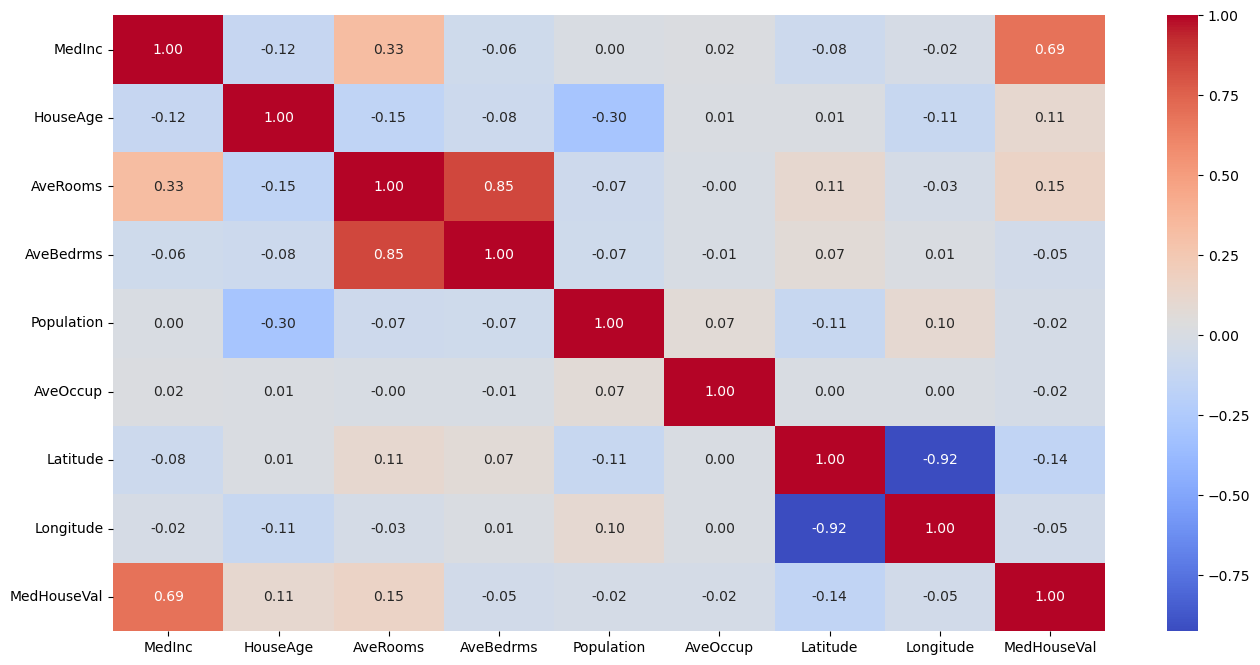

In [20]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
corr=df.corr(numeric_only=True).drop('House_value',axis=0).drop('House_value',axis=1)
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.show()


In [21]:
corr_pair=corr.unstack()
corr_pair=corr_pair[corr_pair!=1]
corr_pair=corr_pair.drop_duplicates()
pos_corr=round(corr_pair.sort_values(ascending=False).head(3),2)
neg_corr=round(corr_pair.sort_values().head(3),2)
print('Top 3 Positive Co-relation:\n',pos_corr)
print('Top 3 Negative Co-relation:\n',neg_corr)

Top 3 Positive Co-relation:
 AveRooms  AveBedrms      0.85
MedInc    MedHouseVal    0.69
          AveRooms       0.33
dtype: float64
Top 3 Negative Co-relation:
 Latitude  Longitude    -0.92
HouseAge  Population   -0.30
          AveRooms     -0.15
dtype: float64


Q11.
Detect outliers in MedHouseVal using IQR Method.

Calculate:
- Number of outliers
- Percentage of outliers


In [22]:
q1=df['MedHouseVal'].quantile(0.25)
q3=df['MedHouseVal'].quantile(0.75)
iqr=q3-q1
ub=q3+1.5*iqr
lb=q1-1.5*iqr
outlier=df[(df['MedHouseVal']>ub )|( df['MedHouseVal']<lb)]
print('Count of Outliers:',len(outlier))
percent=(len(outlier)/len(df))*100
print('Percentage of Outlier:',round(percent,2),'%')


Count of Outliers: 1071
Percentage of Outlier: 5.19 %


Remove outliers from MedHouseVal and compare:

Before Removal:
- Mean
- Median
- Standard Deviation


In [23]:
df1=df[(df['MedHouseVal']<ub )&( df['MedHouseVal']>lb)]
stat1=df1['MedHouseVal'].agg(['mean','median','std'])
stat=df['MedHouseVal'].agg(['mean','median','std'])
compare=pd.DataFrame({
    'BEFORE':round(stat,2),
    'AFTER':round(stat1,2)
})
compare

,BEFORE,AFTER
mean,2.07,1.91
median,1.80,1.73
std,1.15,0.95



Q15.
Divide HouseAge into bins:

0–10
11–20
21–30
31–40
41–50
50+

For each age group calculate:
- Average House Value
- Average Income



In [24]:
df['House_Age_group']=pd.cut(
    df['HouseAge'],
    bins=[0,10,20,30,40,50,float('inf')],
    labels=['0-10','10-20','20-30','30-40','40-50','50+']
)
list=['0-10','10-20','20-30','30-40','40-50','50+']
counts=df['House_Age_group'].value_counts().reindex(list)
Avg_hv=df.groupby('House_Age_group')['MedHouseVal'].mean()
Avg_inc=df.groupby('House_Age_group')['MedInc'].mean()

avg_bin=pd.DataFrame({
    'No_of_Houses':counts,
    'Average_House_Values(K)':round(Avg_hv*100,2),
    'Average_Income':round(Avg_inc*100000,2)
    
})
avg_bin

C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\3262391619.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Avg_hv=df.groupby('House_Age_group')['MedHouseVal'].mean()
C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\3262391619.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Avg_inc=df.groupby('House_Age_group')['MedInc'].mean()


,No_of_Houses,Average_House_Values(K),Average_Income
House_Age_group,,,
0-10,1569,200.26,455414.89
10-20,4724,191.18,401078.01
20-30,4852,206.80,387137.04
30-40,5617,206.66,377369.71
40-50,2557,205.86,340337.36
50+,1321,273.69,387213.66


# Business Insight

### Older neighborhoods (50+ years) command significantly higher prices. 
### This suggests mature locations may possess desirable characteristics such as established infrastructure, schools, and commercial facilities.

Q16.
Find houses that satisfy ALL conditions:

MedInc > 8
HouseAge > 20
AveRooms > 5
MedHouseVal > 4

Display the top 25 records.


In [25]:
df[(df['MedInc']>8) &  (df['HouseAge']>20) & (df['AveRooms']>5) & (df['MedHouseVal']>4)].head(25)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,House_value,House_value_category,Income_quartiles,House_Age_group
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.52600,452600.0,High,Very High,40-50
155,8.8793,52.0,8.972868,1.131783,861.0,3.337209,37.81,-122.23,4.10300,410300.0,High,Very High,50+
407,8.8342,52.0,8.345205,1.021918,975.0,2.671233,37.89,-122.27,4.30500,430500.0,High,Very High,50+
494,9.3959,52.0,7.512097,0.955645,1366.0,2.754032,37.85,-122.24,5.00001,500001.0,Premium,Very High,50+
510,11.8603,39.0,7.911111,0.984127,808.0,2.565079,37.82,-122.22,5.00001,500001.0,Premium,Very High,30-40
511,13.4990,42.0,8.928358,1.000000,1018.0,3.038806,37.82,-122.22,5.00001,500001.0,Premium,Very High,40-50
512,12.2138,52.0,9.210227,1.039773,1001.0,2.843750,37.82,-122.23,5.00001,500001.0,Premium,Very High,50+
513,8.1872,52.0,8.268293,1.032520,1005.0,2.723577,37.82,-122.23,4.66100,466100.0,High,Very High,50+
514,12.3804,52.0,9.122715,1.033943,1192.0,3.112272,37.82,-122.23,5.00001,500001.0,Premium,Very High,50+
516,8.1194,52.0,7.750000,0.987342,916.0,2.898734,37.83,-122.24,4.71600,471600.0,High,Very High,50+


Q17.
Create a pivot table showing:

Rows:
Income Quartile

Columns:
House_Value_Category

Values:
Average House Value



In [26]:
pivot=df.pivot_table(index='Income_quartiles',columns='House_value_category',values='House_value',aggfunc='mean')
pivot

C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\2065330960.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot=df.pivot_table(index='Income_quartiles',columns='House_value_category',values='House_value',aggfunc='mean')


House_value_category,Low,Medium,High,Premium
Income_quartiles,,,,
Low,72703.274046,154223.805855,362240.322581,500000.857143
Medium,81734.632517,171737.270613,360221.637427,500000.901961
High,87111.694340,190468.914956,364666.516517,500000.912409
Very High,86323.809524,225821.060664,374726.693456,500000.992268


Q18.
Create the following visualizations:

1. Histogram of Median Income
2. Histogram of House Value
3. Boxplot of House Value
4. Scatter Plot:
   MedInc vs MedHouseVal
5. Scatter Plot:
   HouseAge vs MedHouseVal

Write business insights from each chart.




In [27]:
import matplotlib.pyplot as plt
import seaborn as sns


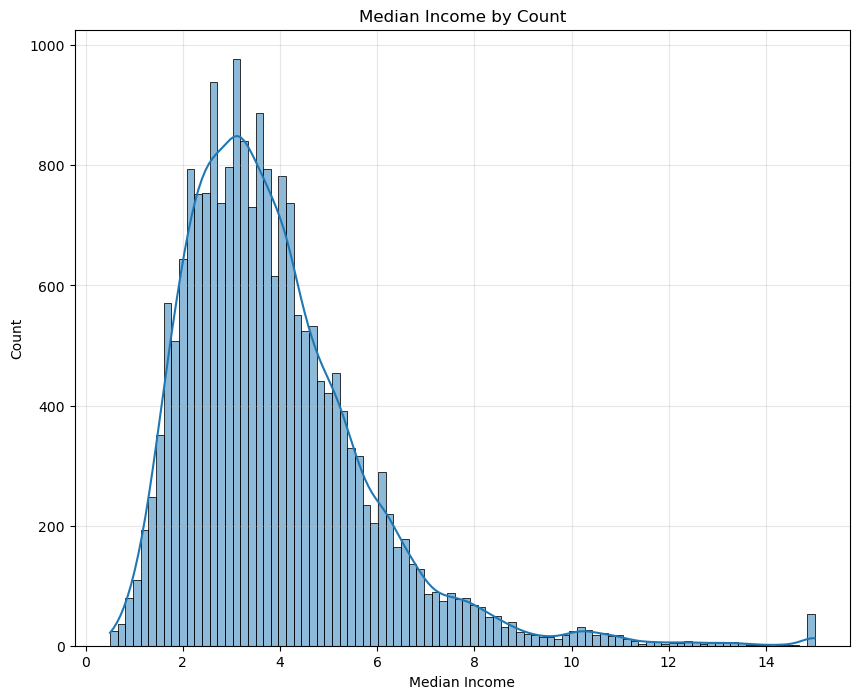

In [28]:
plt.figure(figsize=(10,8))
sns.histplot(data=df,x='MedInc',kde=True)
plt.xlabel('Median Income')
plt.ylabel('Count')
plt.title('Median Income by Count')
plt.grid(True,alpha=0.3)
plt.show()

# Insights: Median Income is right skewed. A large population is between 2 and 5. Income > 10 is very rare.

# Business Insight

### California's housing market is dominated by middle-income households. Premium real-estate projects will target a smaller customer base, while mid-range housing developments can serve a much larger market.

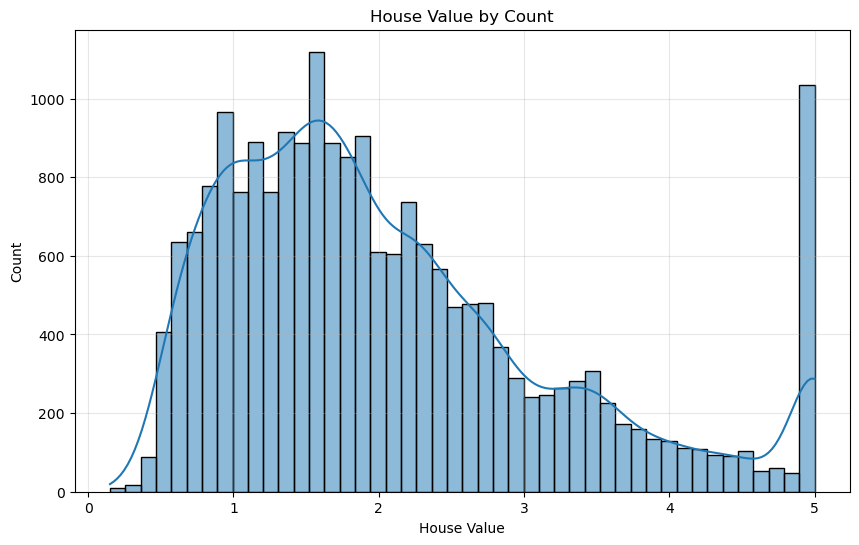

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='MedHouseVal',kde=True)
plt.xlabel('House Value')
plt.ylabel('Count')
plt.title('House Value by Count')
plt.grid(True,alpha=0.3)
plt.show()

# Insights: House Value is also Right Skewed. Most house values are capped between 1 and 3. There is a huge spike at 5
# which means target variable is capped at 5 where a signoficant amount of data lies. This can considerably reduced the model performance.

# Business Insight

### Demand is likely strongest in affordable and mid-market housing segments. 
### Real-estate companies may generate higher sales volume in these segments compared to luxury properties.

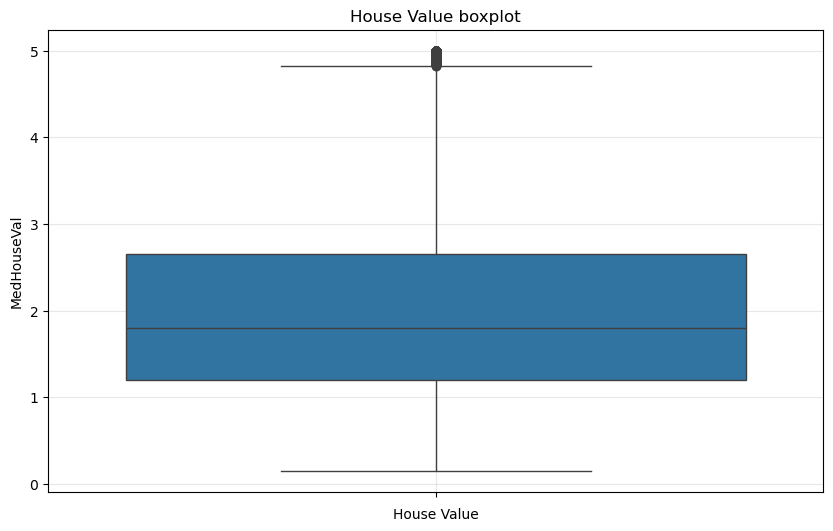

Median: 1.797
Q1: 1.196
Q3: 2.6472499999999997


In [30]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,y='MedHouseVal')
plt.xlabel('House Value')

plt.title('House Value boxplot')
plt.grid(True,alpha=0.3)
plt.show()
print('Median:',df['MedHouseVal'].median())
print('Q1:',q1)
print('Q3:',q3)

# Insights: Few values are above above whiskers capped upto 5.

# Business Insight

### These outliers may represent luxury markets. 
### Analyzing such districts separately can help identify high-value investment opportunities and premium customer segments.

In [31]:
df.groupby('Income_quartiles')['MedHouseVal'].agg(['mean','count'])

C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\1841961703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Income_quartiles')['MedHouseVal'].agg(['mean','count'])


,mean,count
Income_quartiles,,
Low,1.229929,5160
Medium,1.718111,5160
High,2.158627,5160
Very High,3.167567,5160


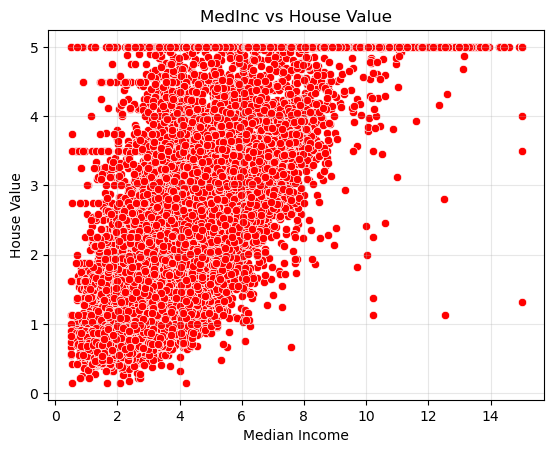

np.float64(0.6880752079585478)

In [32]:
sns.scatterplot(data=df,x='MedInc',y='MedHouseVal',color='red')
plt.xlabel('Median Income')
plt.ylabel('House Value')

plt.title('MedInc vs House Value')
plt.grid(True,alpha=0.3)
plt.show()
df['MedInc'].corr(df['House_value'])

# Insights: Moderately strong Positive Corelation between Income and Housevalue. 
 #   Income can use used as a significant feature describing target variable House Value.

# Business Insight

### Income is a strong indicator of purchasing power. 
### Before launching a project, developers should analyze neighborhood income levels to estimate achievable selling prices.

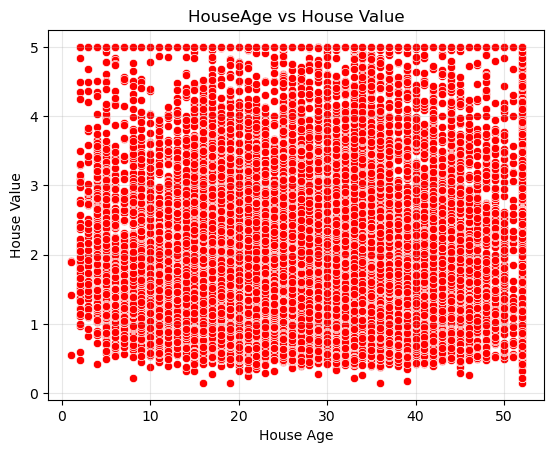

np.float64(0.10562341249320994)

In [33]:
sns.scatterplot(data=df,x='HouseAge',y='MedHouseVal',color='red')
plt.xlabel('House Age')
plt.ylabel('House Value')

plt.title('HouseAge vs House Value')
plt.grid(True,alpha=0.3)
plt.show()
df['HouseAge'].corr(df['House_value'])

# Insights: Not any Significant relationship between House value and  House age. House value is spread accross all house age category.  

# Business Insight

### Customers appear to value location and neighborhood characteristics more than the age of the property. 
### Renovation investments may not always guarantee significant price increases.

Q19.
Using NumPy, create a Risk_Category column:

If Population > 75th Percentile
AND AveOccup > 75th Percentile
→ High Risk

Else
→ Normal

Find:
- Count
- Percentage
- Average House Value by Risk Category


In [34]:
population_75=np.percentile(df['Population'],75)
aveoccup_75=np.percentile(df['AveOccup'],75)
df['Risk_Category']=np.where((df['Population']>population_75) & (df['AveOccup']>aveoccup_75),'High Risk','Normal')
count=df['Risk_Category'].value_counts()
percent=df['Risk_Category'].value_counts(normalize=True)*100
Avg_hv=df.groupby('Risk_Category')['House_value'].mean()
out=pd.DataFrame({
    'Count':count,
    'Percentage':percent,
    'Average_House_Value':Avg_hv
})
out


,Count,Percentage,Average_House_Value
Risk_Category,,,
High Risk,1876,9.089147,167676.391258
Normal,18764,90.910853,210772.924270


# Business Insight

### Segmentation helps prioritize investments.
### Low-risk, high-value regions can be targeted for premium projects, while high-risk regions may require more cautious investment strategies.

Q20. CAPSTONE BUSINESS ANALYSIS

Prepare a complete EDA report answering:

1. Which factor affects house value the most?
2. Do richer areas have more expensive houses?
3. Does house age increase property value?
4. What income range has the highest house prices?
5. Are densely populated areas more expensive?
6. What are the top 10 business insights?
7. What recommendations would you give to a real-estate company?

Use:
- Pandas extensively
- NumPy where appropriate
- Matplotlib
- Seaborn
- GroupBy
- Pivot Tables
- Correlation Analysis
- Feature Engineering

Deliver findings using both tables and visualizations.


In [35]:
corr=df.drop(columns={'House_value'}).corr(numeric_only=True)['MedHouseVal'].sort_values()
corr=corr[corr!=1]
corr.sort_values(ascending=False)


MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64

In [36]:
df['Income_Bucket']=pd.qcut(
    df['MedInc'],
    q=4,
    labels=['Low','Medium','High','Very High']
)
avg_house_value=round(df.groupby('Income_Bucket')['House_value'].mean(),2)
avg_house_value

C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\2255733276.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_house_value=round(df.groupby('Income_Bucket')['House_value'].mean(),2)


Income_Bucket
Low          122992.85
Medium       171811.06
High         215862.68
Very High    316756.68
Name: House_value, dtype: float64

Text(0.5, 1.0, 'Average House Value as per Income Category')

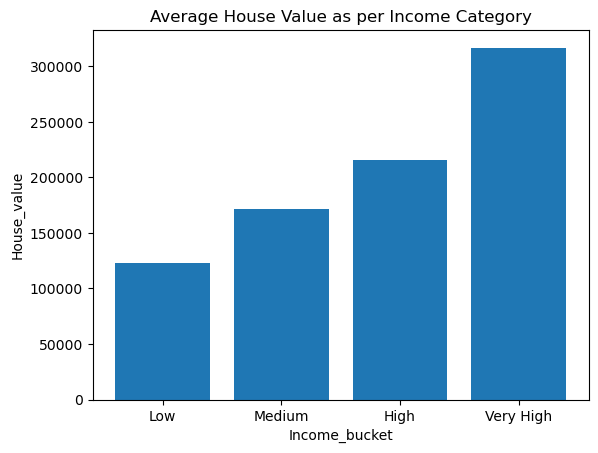

In [37]:
plt.bar(height=avg_house_value.values,x=avg_house_value.index)
plt.xlabel('Income_bucket')
plt.ylabel('House_value')
plt.title('Average House Value as per Income Category')

# Yes, Richer area is having higher House Value 

In [38]:
avg_house_value_age=round(df.groupby('House_Age_group')['House_value'].mean(),2)
avg_house_value_age

C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\585291838.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_house_value_age=round(df.groupby('House_Age_group')['House_value'].mean(),2)


House_Age_group
0-10     200263.25
10-20    191181.63
20-30    206801.59
30-40    206662.17
40-50    205860.40
50+      273687.56
Name: House_value, dtype: float64

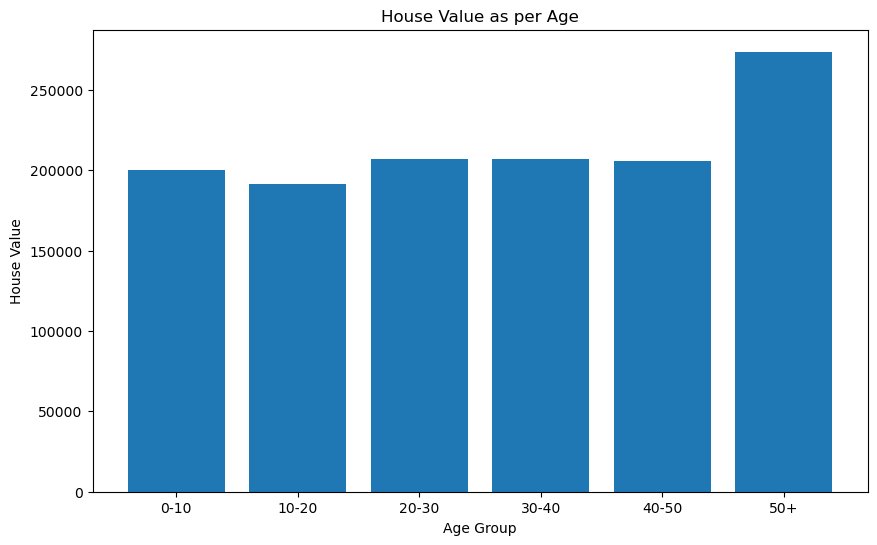

In [39]:
plt.figure(figsize=(10,6))
plt.bar(height=avg_house_value_age.values,x=avg_house_value_age.index)
plt.xlabel('Age Group')
plt.ylabel('House Value')
plt.title('House Value as per Age')
plt.show()

# No, House Age is not significantly causes the increment of House Value

In [40]:
dfx=df.groupby('Income_Bucket')['MedInc'].agg(['min','max'])
dfx['Range']=dfx['max']-dfx['min']
dfx.rename(columns={'min':'Min','max':'Max'})
pd.concat((dfx,avg_house_value),axis=1)

C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\1913628386.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfx=df.groupby('Income_Bucket')['MedInc'].agg(['min','max'])


,min,max,Range,House_value
Income_Bucket,,,,
Low,0.4999,2.5625,2.0626,122992.85
Medium,2.5637,3.5347,0.9710,171811.06
High,3.5349,4.7431,1.2082,215862.68
Very High,4.7437,15.0001,10.2564,316756.68


## Very High Income Bucket(4.74 to 15.00) having house with highest house value

In [41]:
df['Population_Category']=pd.qcut(
    df['Population'],
    q=5,
    labels=['Very Low','Low','Medium','High','Very High']
)
avg_hv_population=df.groupby('Population_Category')['House_value'].mean()
avg_hv_population

C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\1269540752.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_hv_population=df.groupby('Population_Category')['House_value'].mean()


Population_Category
Very Low     212130.922090
Low          213422.319139
Medium       205920.731909
High         201479.718742
Very High    201308.494055
Name: House_value, dtype: float64

Text(0.5, 1.0, 'House Price as per Population')

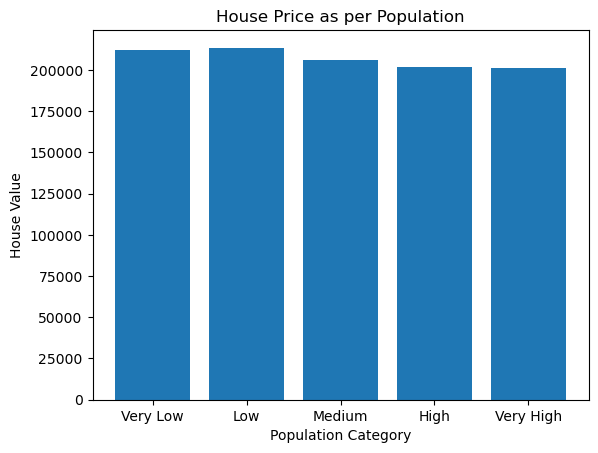

In [42]:
plt.bar(x=avg_hv_population.index,height=avg_hv_population.values)
plt.xlabel('Population Category')
plt.ylabel('House Value')
plt.title('House Price as per Population')

In [43]:
df['Population_Category'].value_counts()

Population_Category
High         4135
Very Low     4133
Low          4133
Very High    4121
Medium       4118
Name: count, dtype: int64

In [44]:
dfy=df.groupby('Population_Category')['House_value'].agg(['min','max'])
dfy['Range']=dfy['max']-dfy['min']
dfy['Population_Count']=df['Population_Category'].value_counts()
dfy.rename(columns={
    'min':'Minimum_House_Value',
    'max':'Maximum_house_Value',
    'Range':'Range_of_house_value'
})

C:\Users\soumy\AppData\Local\Temp\ipykernel_23884\3658794774.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfy=df.groupby('Population_Category')['House_value'].agg(['min','max'])


,Minimum_House_Value,Maximum_house_Value,Range_of_house_value,Population_Count
Population_Category,,,,
Very Low,14999.0,500001.0,485002.0,4133
Low,26600.0,500001.0,473401.0,4133
Medium,22500.0,500001.0,477501.0,4118
High,26900.0,500001.0,473101.0,4135
Very High,22500.0,500001.0,477501.0,4121


### Insights: Population is not a strong predicting factor for The House Value

### Geographical Analysis:

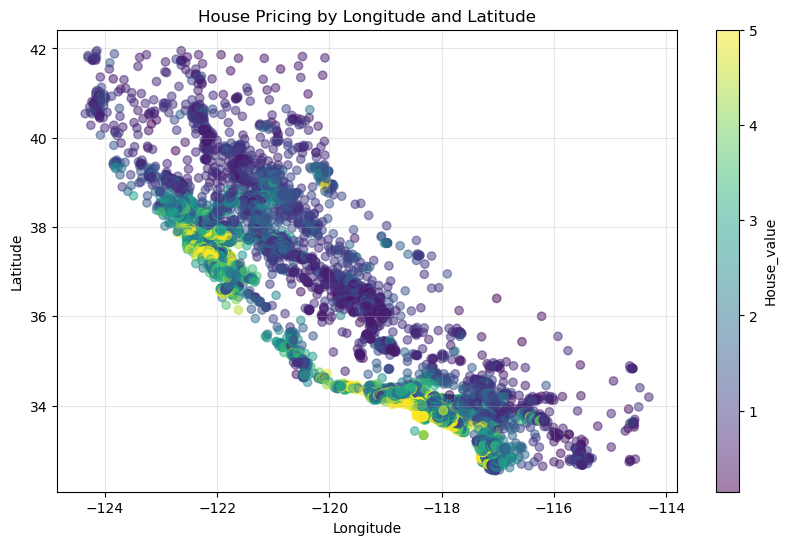

In [45]:
plt.figure(figsize=(10,6))
plt.scatter(data=df,y='Latitude',x='Longitude',c='MedHouseVal',alpha=0.5)
plt.colorbar(label='House_value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('House Pricing by Longitude and Latitude')
plt.grid(True,alpha=0.3)
plt.show()

# Insights: 
- House prices are not uniformly distributed across California. Geographic location appears to be a major factor influencing housing values.
- The brightest yellow-green regions correspond to the highest house values, while dark purple regions represent lower-valued houses.

In [46]:
print('-'*149)

-----------------------------------------------------------------------------------------------------------------------------------------------------


# Linear regression Model:

In [47]:
corr=df.drop(columns={'House_value'},axis=1).corr(numeric_only=True)['MedHouseVal']
corr=corr[corr!=1]
pos=corr.sort_values(ascending=False).head(3)
neg=corr.sort_values().head(3)
feature=pos.index.tolist()+neg.index.tolist()
feature




['MedInc', 'AveRooms', 'HouseAge', 'Latitude', 'AveBedrms', 'Longitude']

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x=df[feature]
y=df['MedHouseVal']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
pred_actual=pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':y_pred
})
pred_actual


,Actual,Predicted
0,4.220,2.140870
1,1.375,1.762160
2,1.529,2.025012
3,2.139,2.435611
4,3.722,2.791888
...,...,...
4123,1.985,2.062514
4124,1.653,1.671075
4125,2.125,1.880021
4126,1.036,1.290940


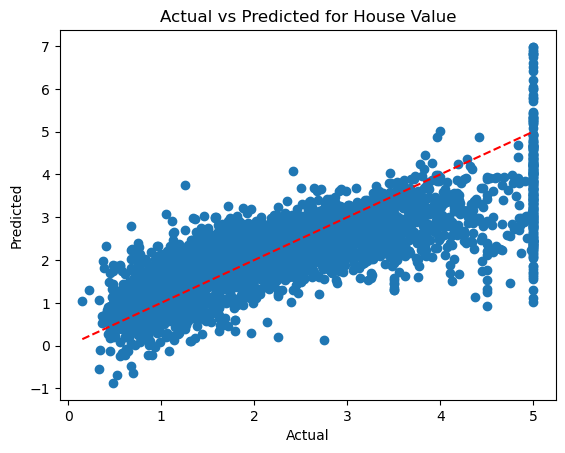

In [49]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted for House Value')

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)


    

Text(0.5, 1.0, 'Residual Plot for Correlative Features Model')

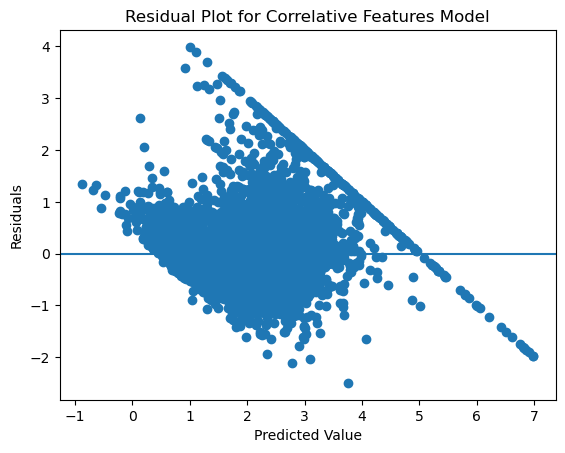

In [50]:
# Residual Plot for model
plt.scatter(y_pred,y_test-y_pred)
plt.axhline(y=0)
plt.xlabel('Predicted Value')
plt.ylabel('Residuals')
plt.title('Residual Plot for Correlative Features Model')

Text(0.5, 1.0, 'Distribution of Residuals')

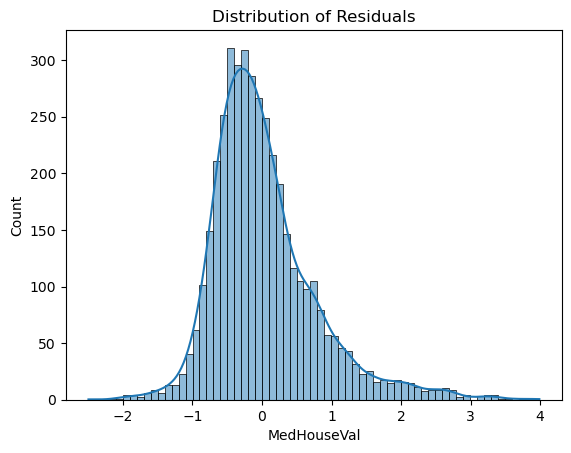

In [51]:
residuals=y_test-y_pred
sns.histplot(residuals,kde=True)
plt.title('Distribution of Residuals')

In [52]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
Coefficient=model.coef_
intercept=model.intercept_
r2=r2_score(y_test,y_pred)
n=len(y_test)
p=len(x_test.columns)
adjusted_r2=1-(((1-r2)*(n-1))/(n-p-1))
print('Mean Absolute Error:',mae)
print('Mean Squared Error:',mse)
print('Root mean Squared Error',rmse)
print('R2 Score:',r2)
print('Adjusted R2 Score:',adjusted_r2)
print('Coefficient:',Coefficient)
print('Intercept:',intercept)


Mean Absolute Error: 0.5452500664529104
Mean Squared Error: 0.5569064283614116
Root mean Squared Error 0.7462616353273238
R2 Score: 0.5983931980704486
Adjusted R2 Score: 0.5978084757186948
Coefficient: [ 0.42982078 -0.09815916  0.00960896 -0.42454043  0.58846588 -0.43969188]
Intercept: -37.435141863336305


In [53]:
# coefficient Dataframe for Model
model_coef_intercept=pd.DataFrame({
    'Feature':x_test.columns,
    'Coefficient':Coefficient,
    'Intercept':intercept
})
model_coef_intercept.sort_values(by='Coefficient',ascending=False)

,Feature,Coefficient,Intercept
4,AveBedrms,0.588466,-37.435142
0,MedInc,0.429821,-37.435142
2,HouseAge,0.009609,-37.435142
1,AveRooms,-0.098159,-37.435142
3,Latitude,-0.424540,-37.435142
5,Longitude,-0.439692,-37.435142


In [54]:
train_score = model.score(x_train,y_train)
test_score = model.score(x_test,y_test)
print('train_score',train_score)
print('test_score',test_score)

train_score 0.6065586875849969
test_score 0.5983931980704486


      Actual  Predicted
0      0.980   1.584169
1      0.475   0.888543
2      1.500   2.563479
3      3.374   2.913785
4      1.399   1.799794
...      ...        ...
4123   1.194   1.614489
4124   1.150   1.705806
4125   2.791   2.727195
4126   0.896   0.811355
4127   2.750   2.106449

[4128 rows x 2 columns]


Text(0.5, 1.0, 'Actual vs Predicted for House Value')

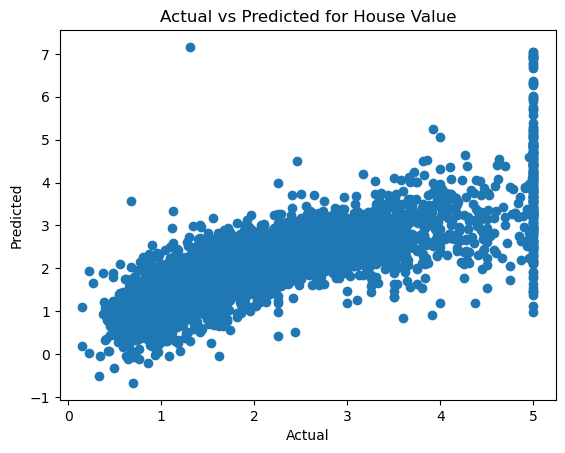

In [55]:
x=df.select_dtypes(include='number').drop(['MedHouseVal','House_value'],axis=1)
y=df['MedHouseVal']
x_train1,x_test1,y_train1,y_test1=train_test_split(x,y,test_size=0.2)
model1=LinearRegression()
model1.fit(x_train1,y_train1)
y_pred1=model1.predict(x_test1)
pred_actual1=pd.DataFrame({
    'Actual':y_test1.values,
    'Predicted':y_pred1
})
print(pred_actual1)
plt.scatter(y_test1,y_pred1)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted for House Value')


In [56]:
train_score = model1.score(x_train1,y_train1)
test_score = model1.score(x_test1,y_test1)
print('train_score',train_score)
print('test_score',test_score)

train_score 0.6062024804377667
test_score 0.6062090248070982


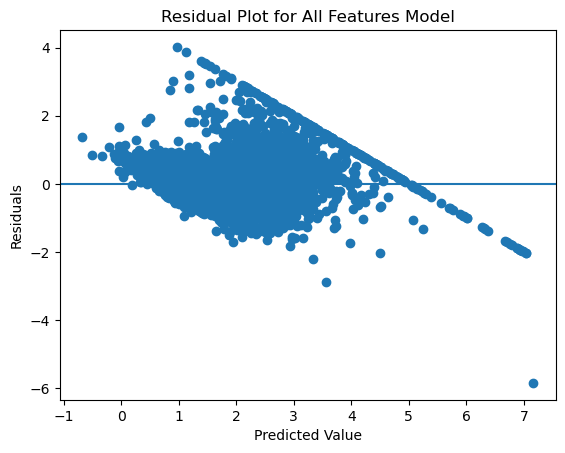

In [57]:
plt.scatter(y_pred1,y_test1-y_pred1)
plt.axhline(y=0)
plt.xlabel('Predicted Value')
plt.ylabel('Residuals')
plt.title('Residual Plot for All Features Model')
plt.show()

Text(0.5, 1.0, 'Distribution of Residuals')

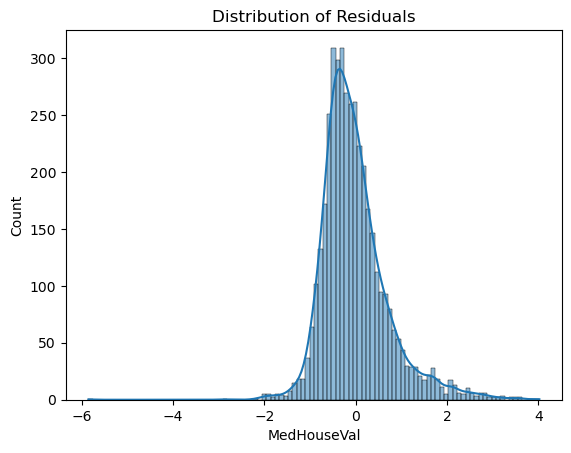

In [58]:
residuals=y_test1-y_pred1
sns.histplot(residuals,kde=True)
plt.title('Distribution of Residuals')


In [59]:
mae1=mean_absolute_error(y_test1,y_pred1)
mse1=mean_squared_error(y_test1,y_pred1)
rmse1=np.sqrt(mse1)
Coefficient1=model1.coef_
intercept1=model1.intercept_
r21=r2_score(y_test1,y_pred1)
n=len(y_test1)
p=len(x_test1.columns)
adjusted_r21=1-(((1-r21)*(n-1))/(n-1-p))
print('Mean Absolute Error:',mae1)
print('Mean Squared Error:',mse1)
print('Root mean Squared Error',rmse1)
print('R2 Score:',r21)
print('Adjusted R2 Score:',adjusted_r21)
print('Coefficient:',Coefficient1)
print('Intercept:',intercept1)



Mean Absolute Error: 0.5289859491699336
Mean Squared Error: 0.5256181519087924
Root mean Squared Error 0.7249952771630946
R2 Score: 0.6062090248070982
Adjusted R2 Score: 0.6054441964988817
Coefficient: [ 4.37864464e-01  9.54981024e-03 -1.07061988e-01  6.40379805e-01
 -4.84001065e-06 -3.47449896e-03 -4.18956851e-01 -4.33323605e-01]
Intercept: -36.88434907639761


In [60]:
# coefficient Dataframe for Model1
model_coef_intercept1=pd.DataFrame({
    'Feature':x_test1.columns,
    'Coefficient':Coefficient1,
    'Intercept':intercept1
})
model_coef_intercept1.sort_values(by='Coefficient',ascending=False)

,Feature,Coefficient,Intercept
3,AveBedrms,0.640380,-36.884349
0,MedInc,0.437864,-36.884349
1,HouseAge,0.009550,-36.884349
4,Population,-0.000005,-36.884349
5,AveOccup,-0.003474,-36.884349
2,AveRooms,-0.107062,-36.884349
6,Latitude,-0.418957,-36.884349
7,Longitude,-0.433324,-36.884349


In [61]:
model_performance=pd.DataFrame({
    'Attributes':['Mean Absolute Error','Mean Squared Error','Root Mean Squared Value','R2 Score','Adjusted R2 Score '],
    'Model':[mae,mse,rmse,r2,adjusted_r2],
    'Model1':[mae1,mse1,rmse1,r21,adjusted_r21]
})
model_performance

,Attributes,Model,Model1
0,Mean Absolute Error,0.545250,0.528986
1,Mean Squared Error,0.556906,0.525618
2,Root Mean Squared Value,0.746262,0.724995
3,R2 Score,0.598393,0.606209
4,Adjusted R2 Score,0.597808,0.605444


In [62]:
#Feature Comparison between models
feature_compare=pd.DataFrame({
    'Model':['Top Correlated Feature','All Numeric Feature'],
    'R2_Score':[r2,r21],
    'RMSE':[rmse,rmse1],
    'MAE':[mae,mae1],
    'Adjusted R2':[adjusted_r2,adjusted_r21]
})
feature_compare

,Model,R2_Score,RMSE,MAE,Adjusted R2
0,Top Correlated Feature,0.598393,0.746262,0.545250,0.597808
1,All Numeric Feature,0.606209,0.724995,0.528986,0.605444


# Why model1 performs better than model
The all-feature model achieved slightly higher predictive accuracy because
it incorporates additional information not captured by the six most correlated variables.

# Executive Summary Table:
| Metric                | Result                                 |
| --------------------- | -------------------------------------- |
| Dataset Size          | 20,640                                 |
| Strongest Predictor   | Median Income                          |
| Best R²               | ~0.61                                  |
| Best Model            | All Features Model                     |
| Main Business Insight | Income strongly influences house value |


# Final Conclusion

Median Income emerged as the strongest determinant of housing prices.

A Linear Regression model using all numerical variables achieved an R² score of 0.614,
indicating that approximately 61% of house price variation can be explained by the available features.

Real-estate firms should prioritize high-income districts for premium housing developments 
and use income-driven segmentation strategies to improve investment decisions.

# Top 10 Insights :
- 1.Median Income is the strongest driver of house prices
- 2.Very High Income areas command premium prices
- 3.House Age has limited impact on price
- 4.Housing prices are highly concentrated in middle-value ranges
- 5.Presence of luxury housing clusters
- 6.Income inequality creates distinct housing segments
- 7.Property values show a ceiling effect
- 8.Geographic factors likely influence prices.
- 9.Population alone does not drive house prices.
- 10.Wealthier neighborhoods provide better investment opportunities
    

# Business Insights For Company :
- 1. Focus marketing efforts on high-income neighborhoods
- 2. Prioritize properties in areas with strong median income growth
- 3. Segment customers by income level
- 4. Invest more in premium and luxury markets
- 5. Use Median Income as a key pricing indicator
- 6. Avoid relying solely on house age
- 7. Target affluent areas for new developments
- 8. Use data-driven valuation models
- 9. Identify undervalued properties in high-income districts
- 10. Expand operations in areas with rising demand

# Key Findings
- 1.Median Income is the strongest driver of house prices.
- 2.Very-high-income areas have 2.6× higher average house values than low-income areas.
- 3.House Age has limited impact on property prices.
- 4.Most properties belong to the mid-market segment.
- 5.Mature neighborhoods (50+ years old) exhibit higher average prices.
- 6.Population size alone does not determine property value.
- 7.Luxury housing markets represent niche but highly profitable opportunities.
- 8.Income-based customer segmentation can improve marketing effectiveness.
- 9.Premium developments should target affluent neighborhoods.
- 10.Data-driven pricing strategies can significantly improve investment decisions.

# Limitations

- House values are capped at $500,000.
- Dataset does not include crime rates.
- Dataset does not include school quality.
- Dataset represents historical California housing data.

## Converting to CSV

In [63]:
df.to_csv('California_Housing_cleaned.csv',index=False)

In [64]:
import os
os.getcwd()

'C:\\Users\\soumy'